In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [6]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df["message"].duplicated().sum()

np.int64(403)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(5169, 2)

In [12]:
df["message"].duplicated().sum()

np.int64(0)

In [13]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [14]:
df["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

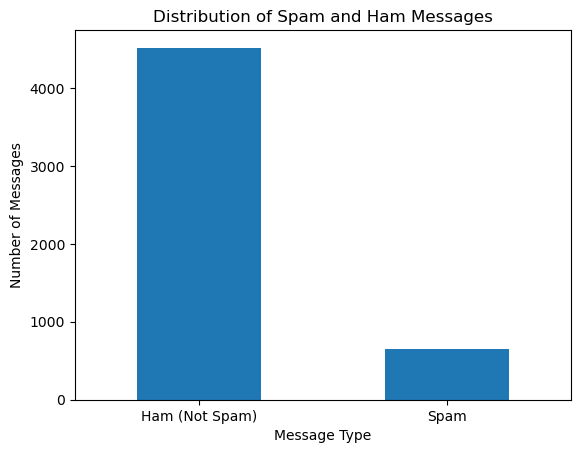

In [19]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts()

class_counts.index = ["Ham (Not Spam)" if x == "ham" else "Spam"
                      for x in class_counts.index]

class_counts.plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [16]:
df["message_length"] = df["message"].apply(len)

In [17]:
df[["message", "message_length"]].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
df.groupby("label")["message_length"].mean()

label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64

In [20]:
df[df["label"] == "spam"]["message"].head(10)

2     Free entry in 2 a wkly comp to win FA Cup fina...
5     FreeMsg Hey there darling it's been 3 week's n...
8     WINNER!! As a valued network customer you have...
9     Had your mobile 11 months or more? U R entitle...
11    SIX chances to win CASH! From 100 to 20,000 po...
12    URGENT! You have won a 1 week FREE membership ...
15    XXXMobileMovieClub: To use your credit, click ...
19    England v Macedonia - dont miss the goals/team...
34    Thanks for your subscription to Ringtone UK yo...
42    07732584351 - Rodger Burns - MSG = We tried to...
Name: message, dtype: object

In [21]:
df[df["label"] == "ham"]["message"].head(10)

0     Go until jurong point, crazy.. Available only ...
1                         Ok lar... Joking wif u oni...
3     U dun say so early hor... U c already then say...
4     Nah I don't think he goes to usf, he lives aro...
6     Even my brother is not like to speak with me. ...
7     As per your request 'Melle Melle (Oru Minnamin...
10    I'm gonna be home soon and i don't want to tal...
13    I've been searching for the right words to tha...
14                  I HAVE A DATE ON SUNDAY WITH WILL!!
16                           Oh k...i'm watching here:)
Name: message, dtype: object

In [22]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

In [23]:
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
X = df["message"]
y = df["label"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4135
Testing messages: 1034


In [27]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
label
0    3613
1     522
Name: count, dtype: int64

Testing labels:
label
0    903
1    131
Name: count, dtype: int64


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [29]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7591)
Testing TF-IDF shape: (1034, 7591)


In [31]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
y_pred = model.predict(X_test_tfidf)
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [34]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9516441005802708
Accuracy (%): 95.16441005802709


In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.62      0.76       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[903   0]
 [ 50  81]]


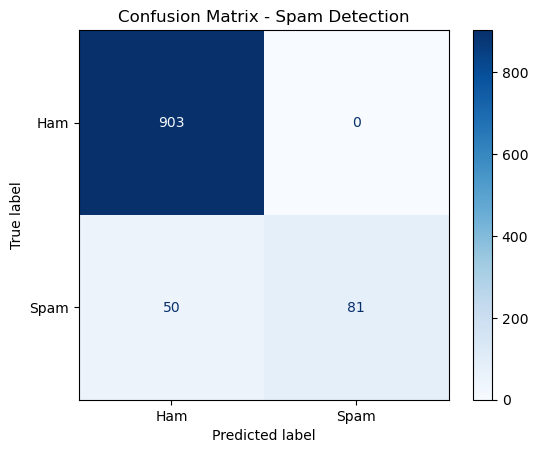

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Spam Detection")
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

balanced_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
balanced_pred = balanced_model.predict(X_test_tfidf)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    balanced_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.92      0.91      0.92       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



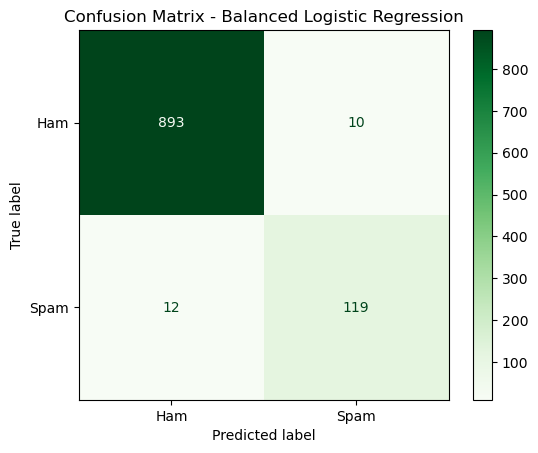

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

balanced_cm = confusion_matrix(y_test, balanced_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=balanced_cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [45]:
#test the model with real messages
message = ["Congratulations! You have won a free prize! Click now to claim your reward!"]

message_tfidf = tfidf.transform(message)

prediction = balanced_model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("NOT SPAM")

SPAM


In [46]:
message = ["Hey, are you coming to class tomorrow?"]

message_tfidf = tfidf.transform(message)

prediction = balanced_model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("NOT SPAM")

NOT SPAM


In [48]:
def predict_message(message):
    message_tfidf = tfidf.transform([message])
    prediction = balanced_model.predict(message_tfidf)

    if prediction[0] == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

predict_message("Congratulations! You won $1000!")

'SPAM'

In [49]:
predict_message("Can you send me the assignment?")

'NOT SPAM'

In [50]:
test_messages = [
    "Congratulations! You won a free iPhone!",
    "URGENT! Claim your cash prize now!",
    "Hey, what time are we meeting tomorrow?",
    "Can you send me the notes from today's class?",
    "FREE entry to win $5000! Text WIN now!",
    "I will call you when I reach home."
]

for msg in test_messages:
    print("Message:", msg)
    print("Prediction:", predict_message(msg))
    print("-" * 60)

Message: Congratulations! You won a free iPhone!
Prediction: SPAM
------------------------------------------------------------
Message: URGENT! Claim your cash prize now!
Prediction: SPAM
------------------------------------------------------------
Message: Hey, what time are we meeting tomorrow?
Prediction: NOT SPAM
------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: NOT SPAM
------------------------------------------------------------
Message: FREE entry to win $5000! Text WIN now!
Prediction: SPAM
------------------------------------------------------------
Message: I will call you when I reach home.
Prediction: NOT SPAM
------------------------------------------------------------


In [51]:
balanced_model.predict_proba(message_tfidf)

array([[0.9129088, 0.0870912]])

In [52]:
def predict_message(message):
    message_tfidf = tfidf.transform([message])

    prediction = balanced_model.predict(message_tfidf)
    probabilities = balanced_model.predict_proba(message_tfidf)

    spam_probability = probabilities[0][1]
    ham_probability = probabilities[0][0]

    if prediction[0] == 1:
        result = "SPAM"
        confidence = spam_probability
    else:
        result = "NOT SPAM"
        confidence = ham_probability

    return result, confidence

In [53]:
result, confidence = predict_message(
    "Congratulations! You won a free iPhone!"
)

print("Prediction:", result)
print("Confidence:", f"{confidence * 100:.2f}%")

Prediction: SPAM
Confidence: 68.07%


In [54]:
result, confidence = predict_message(
    "Hey, are you coming to class tomorrow?"
)

print("Prediction:", result)
print("Confidence:", f"{confidence * 100:.2f}%")

Prediction: NOT SPAM
Confidence: 91.29%


In [ ]:
#GUI
import tkinter as tk

import tkinter as tk
import joblib

# Load saved model and TF-IDF
tfidf = joblib.load("tfidf.pkl")
model = joblib.load("spam_model.pkl")


# Predict message
def predict_message(message):
    message_tfidf = tfidf.transform([message])

    prediction = model.predict(message_tfidf)
    probability = model.predict_proba(message_tfidf)

    if prediction[0] == 1:
        result = "SPAM"
        confidence = probability[0][1]
    else:
        result = "NOT SPAM"
        confidence = probability[0][0]

    return result, confidence


# Check button function
def check_message():
    message = message_box.get("1.0", tk.END).strip()

    if message == "":
        result_label.config(text="Please enter a message")
        confidence_label.config(text="")
        return

    result, confidence = predict_message(message)

    result_label.config(text="Result: " + result)
    confidence_label.config(
        text="Confidence: " + str(round(confidence * 100, 2)) + "%"
    )


# Clear button function
def clear_message():
    message_box.delete("1.0", tk.END)
    result_label.config(text="Result: ")
    confidence_label.config(text="Confidence: ")


# Create window
root = tk.Tk()
root.title("Email Spam Detector")
root.geometry("550x550")


# Title
title = tk.Label(
    root,
    text="EMAIL SPAM DETECTOR",
    font=("Arial", 18, "bold")
)
title.pack(pady=25)


# Instruction
instruction = tk.Label(
    root,
    text="Enter or paste your message below:",
    font=("Arial", 11)
)
instruction.pack()


# Message box
message_box = tk.Text(
    root,
    height=8,
    width=55,
    font=("Arial", 11)
)
message_box.pack(pady=15)


# Check button
check_button = tk.Button(
    root,
    text="CHECK MESSAGE",
    font=("Arial", 11, "bold"),
    command=check_message
)
check_button.pack(pady=5)


# Result
result_label = tk.Label(
    root,
    text="Result: ",
    font=("Arial", 14, "bold")
)
result_label.pack(pady=15)


# Confidence
confidence_label = tk.Label(
    root,
    text="Confidence: ",
    font=("Arial", 11)
)
confidence_label.pack()


# Clear button
clear_button = tk.Button(
    root,
    text="CLEAR",
    font=("Arial", 10),
    command=clear_message
)
clear_button.pack(pady=20)


# Start GUI
root.mainloop()

In [6]:
import joblib

saved_tfidf = joblib.load("tfidf.pkl")
saved_model = joblib.load("spam_model.pkl")

print("Models loaded successfully!")

Models loaded successfully!


In [84]:
import os

print(os.path.exists("tfidf.pkl"))
print(os.path.exists("spam_model.pkl"))


True
True


In [7]:
message = "Congratulations! You won a free iPhone!"

message_tfidf = saved_tfidf.transform([message])

prediction = saved_model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("NOT SPAM")

SPAM


In [8]:
tfidf = joblib.load("tfidf.pkl")
model = joblib.load("spam_model.pkl")

In [9]:
def predict_message(message):
    message_tfidf = tfidf.transform([message])

    prediction = model.predict(message_tfidf)

    if prediction[0] == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

In [10]:
print(predict_message("Congratulations! You won a free iPhone!"))
print(predict_message("Hey, are we meeting for lunch today?"))

SPAM
NOT SPAM
